# ОПФ для DTMF

Рассмотрим ОПФ на сигналах, полученных из технологии DTMF

In [1]:
from scipy.io import wavfile 
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft

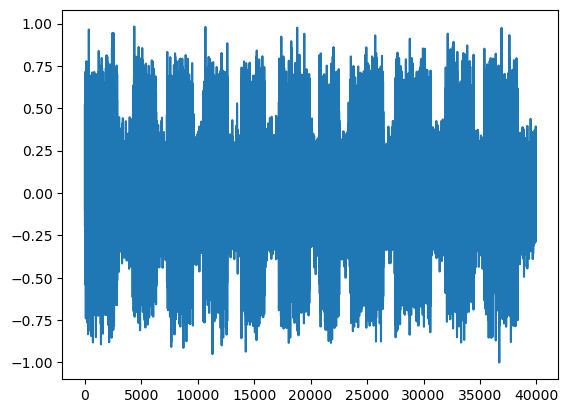

In [2]:
# подгрузка аудиофайла
filename = "source/signals/phoneNumber0.wav"
fs, audio_signal = wavfile.read(filename)
# график
plt.plot(audio_signal)

Построим спектр.

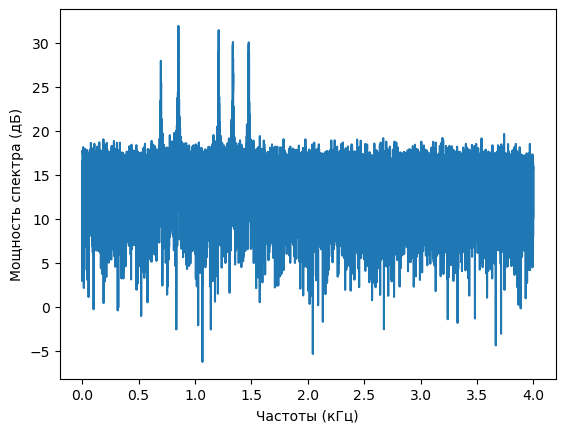

In [5]:
n = len(audio_signal) 
signalFFT = fft(audio_signal)
signalFFT = signalFFT[0:int(np.ceil((n+1)/2.0))] #берём половину спектра
signalFFT_mag = np.abs(signalFFT) # Magnitude
 

plt.figure()
freqAxis = np.arange(0,int(np.ceil((n+1)/2.0)), 1.0) * (fs / n);
plt.plot(freqAxis/1000.0, 10*np.log10(signalFFT_mag)) #Power spectrum
plt.xlabel('Частоты (кГц)'); plt.ylabel('Мощность спектра (дБ)');

Построим спектрограмму. Для этого надо создать экземпляр класса `signal.ShortTimeFFT` с необходимыми параметрами и использовать метод `stft()` для преобразования сигнала.



In [56]:
from scipy import signal

N = 512 # число точек для ДПФ
SFT = signal.ShortTimeFFT(signal.windows.boxcar(N), hop=int(N/2), fs=fs)#,  scale_to='magnitude')
Sx = SFT.stft(audio_signal)  

# Старый вариант STFT
#f, t, Sxx = signal.spectrogram(audio_signal, window = signal.windows.boxcar(512), fs = fs, nfft=512)

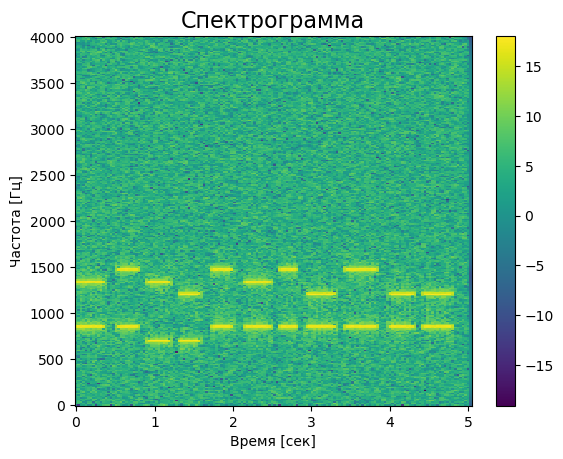

In [58]:
plt.figure()
plt.pcolormesh(SFT.t(len(audio_signal)), SFT.f, 10*np.log10(abs(Sx))) # dB spectrogram
#plt.pcolormesh(SFT.t(len(audio_signal)), SFT.f, abs(Sx))
plt.ylabel('Частота [Гц]')
plt.xlabel('Время [сек]')
plt.title('Спектрограмма',size=16);
plt.colorbar()

plt.show()

Можно использовать различные типы окон.

In [6]:
window = signal.windows.boxcar(51)
window

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

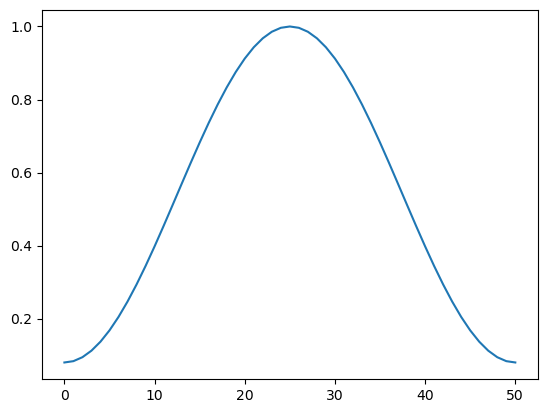

In [7]:
plt.plot(signal.windows.hamming(51))

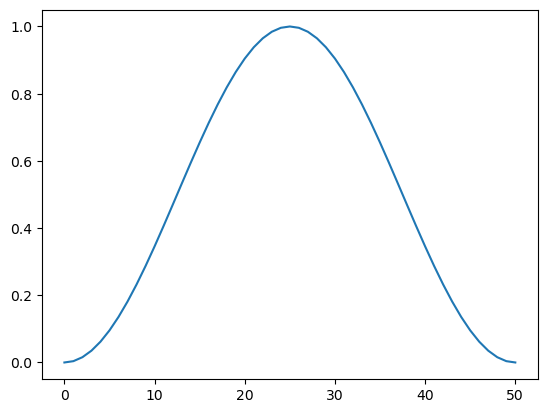

In [74]:
plt.plot(signal.windows.hann(51))

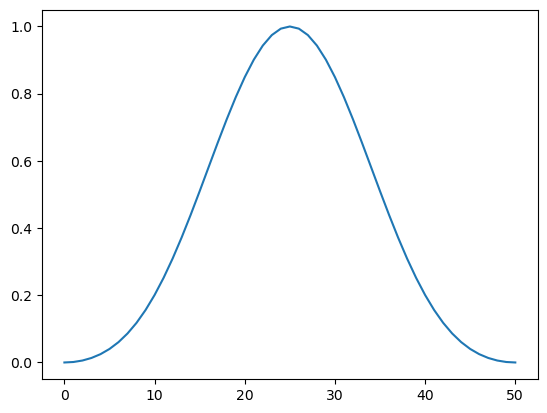

In [9]:
plt.plot(signal.windows.blackman(51))

# ОПФ в задачах классификации

ОПФ для аудио-сигналов часто используют, чтобы выделить признаки аудио-сигналов, которые далее можно использовать в задачах классификации или синтеза звуков.

Рассмотрим задачу класификации звуков с помощью свёрточных нейронных сетей, которые на вход принимают результат ОПФ.

Требуемые библиотеки:
    
    librosa
    torch
    
Рассмотрим датасет ESC-10 из 400 аудио-файлов с записью окружающих звуков. В датасете 10 классов, 40 треков на класс, 5 секунд на файл.

Ссылка на датасет: 
https://dataverse.harvard.edu/file.xhtml?persistentId=doi:10.7910/DVN/YDEPUT/B3VNQW&version=2.0

In [62]:
import numpy as np
import matplotlib.pyplot as plt
import librosa

Библиотека librosa содержит основные инструменты для работы с аудио-сигналами.

Загрузим сигнал и построим его спектрограмму.

In [64]:
data, fs = librosa.load("dataset/001 - Dog bark/1-30344-A.ogg", sr=44000) 
data.shape
time_sec = (len(data)/fs)
print('Длительность сигнала: ', time_sec)

D:\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
D:\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
D:\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


Длительность сигнала:  5.001


Выведем график сигнала и озвучим сигнал.

In [66]:
import IPython
IPython.display.Audio(data, rate=fs)

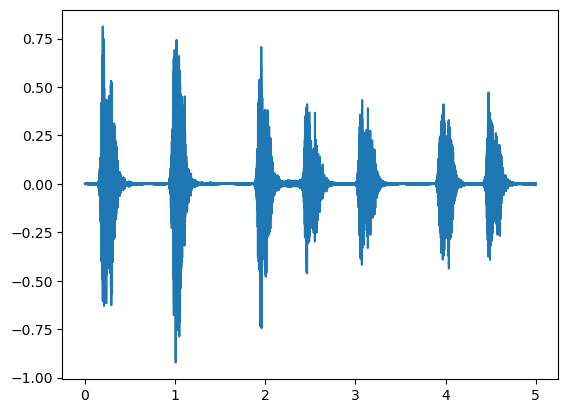

In [68]:
plt.plot(np.arange(0,len(data))/fs,data)

Проделаем ОПФ с помощью метода `librosa.stft()`.
Приведём значения в шкалу дБ, где максимум соответствует 0 дБ.

Метод по умолчанию имеет ширину окна 2048 точек. Расстояние между соседними окнами 512 точек. Также по умолчанию используется окно Ханна.

Размер матрицы ОПФ сигнала: (1025, 430)


Text(0.5, 1.0, 'ОПФ')

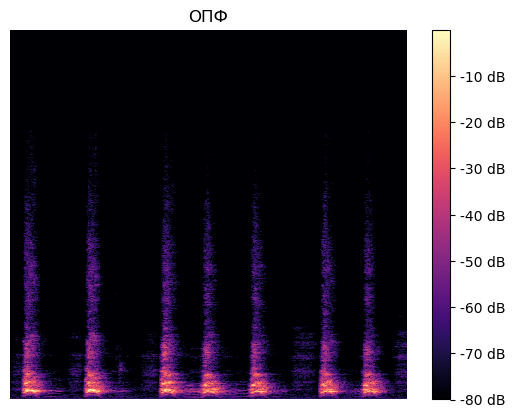

In [76]:
freq = librosa.amplitude_to_db(np.abs(librosa.stft(data)), ref=np.max)
print('Размер матрицы ОПФ сигнала:', freq.shape)
plt.axis('off') # no axis
librosa.display.specshow(freq)
plt.colorbar(format='%+2.0f dB')
plt.title('ОПФ')

### Задача 4

Сформировать модель и обучить на датасете ESC-10.

Цель: обучить модель с точностью accuracy 80% на тестовой выборке.

Основные шаги:

1. Подгрузить файлы, как набор пар (файл, метка класса)
2. Применить STFT к аудио-сигналам, подобрав подходящие параметры. Обеспечить одинаковый размер массивов на выходе.
3. Разделить данные на обучающую и тестовую выборки.
4. Подобрать архитектуру свёрточной ИНС и обучить модель.

Функция ошибки - это кросс-энтропия.

    loss_fn = nn.CrossEntropyLoss()

In [13]:
import os
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

import random

class ESC10Dataset(Dataset):
    def __init__(self, file_paths, labels, sr=44100, n_fft=2048, hop_length=512, n_mels=128, augment=False):
        self.file_paths = file_paths
        self.labels = labels
        self.sr = sr
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.augment = augment
        self.le = LabelEncoder()
        self.encoded_labels = self.le.fit_transform(labels)

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.encoded_labels[idx]
        y, sr = librosa.load(file_path, sr=self.sr)
        if self.augment:
            y = self.apply_augmentation(y)

        stft = librosa.stft(y, n_fft=self.n_fft, hop_length=self.hop_length, window='hann')
        stft_db = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

        stft_norm = (stft_db - stft_db.min()) / (stft_db.max() - stft_db.min())

        desired_shape = (128, 128)
        stft_resized = np.zeros(desired_shape, dtype=np.float32)
        h, w = stft_norm.shape
        h_crop = min(h, desired_shape[0])
        w_crop = min(w, desired_shape[1])
        stft_resized[:h_crop, :w_crop] = stft_norm[:h_crop, :w_crop]

        stft_resized = np.expand_dims(stft_resized, axis=0)
        return torch.tensor(stft_resized, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

    def apply_augmentation(self, y):

        aug_choice = random.choice(['noise', 'shift', 'stretch', 'none'])
        if aug_choice == 'noise':
            noise = np.random.randn(len(y))
            y = y + 0.005 * noise
        elif aug_choice == 'shift':
            shift_range = int(0.1 * len(y))
            shift = np.random.randint(-shift_range, shift_range)
            y = np.roll(y, shift)
        elif aug_choice == 'stretch':
            rate = random.uniform(0.8, 1.2)
            y = librosa.effects.time_stretch(y, rate=rate)
        return y

class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(ImprovedCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def load_esc10_dataset(dataset_path):
    file_paths = []
    labels = []
    for class_name in sorted(os.listdir(dataset_path)):
        class_dir = os.path.join(dataset_path, class_name)
        if os.path.isdir(class_dir):
            for file_name in os.listdir(class_dir):
                if file_name.endswith('.wav') or file_name.endswith('.ogg'):
                    file_paths.append(os.path.join(class_dir, file_name))
                    labels.append(class_name)
    return file_paths, labels

def train_model(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def main(dataset_path):
    file_paths, labels = load_esc10_dataset(dataset_path)
    if len(file_paths) == 0:
        print(f"No audio files found in dataset path: {dataset_path}")
        return
    X_train, X_test, Y_train, Y_test = train_test_split(file_paths, labels, test_size=0.2, random_state=42, stratify=labels)

    train_dataset = ESC10Dataset(X_train, Y_train, augment=True)
    test_dataset = ESC10Dataset(X_test, Y_test, augment=False)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2) # TODO disable workers if windows
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2) # TODO disable workers if windows

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ImprovedCNN(num_classes=10).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    num_epochs = 50
    best_acc = 0.0
    for epoch in range(num_epochs):
        train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_model(model, test_loader, criterion, device)
        print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} - Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_esc10_cnn.pth")
        scheduler.step()
    print(f"Best validation accuracy: {best_acc:.4f}")


In [15]:
dataset_path = "../dataset/ESC-10"  
main(dataset_path)


Epoch 1/50 - Train loss: 3.6131, Train acc: 0.1750 - Val loss: 2.1595, Val acc: 0.2125
Epoch 2/50 - Train loss: 2.3061, Train acc: 0.2500 - Val loss: 2.1913, Val acc: 0.1000
Epoch 3/50 - Train loss: 1.8134, Train acc: 0.3750 - Val loss: 1.9701, Val acc: 0.3375
Epoch 4/50 - Train loss: 1.7946, Train acc: 0.3250 - Val loss: 1.7348, Val acc: 0.5500
Epoch 5/50 - Train loss: 1.6539, Train acc: 0.4531 - Val loss: 1.4876, Val acc: 0.6000
Epoch 6/50 - Train loss: 1.5479, Train acc: 0.4156 - Val loss: 1.2008, Val acc: 0.6250
Epoch 7/50 - Train loss: 1.4492, Train acc: 0.4656 - Val loss: 1.1014, Val acc: 0.6250
Epoch 8/50 - Train loss: 1.3912, Train acc: 0.4781 - Val loss: 1.0762, Val acc: 0.6250
Epoch 9/50 - Train loss: 1.2274, Train acc: 0.6000 - Val loss: 1.0720, Val acc: 0.6500
Epoch 10/50 - Train loss: 1.2811, Train acc: 0.5406 - Val loss: 0.9223, Val acc: 0.6750
Epoch 11/50 - Train loss: 1.1342, Train acc: 0.6156 - Val loss: 0.7690, Val acc: 0.7375
Epoch 12/50 - Train loss: 1.0024, Train a

Задача 4*
Построить классификатор для распознавания звуков в датасете ESC-50 на основе оконного ПФ (точность 50%). (+2 буквы)

Датасет ESC50 :

https://github.com/karolpiczak/ESC-50

In [17]:
import os
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import random

# Dataset class for ESC-50 with data augmentation
class ESC50Dataset(Dataset):
    def __init__(self, dataset_path, sr=44100, n_fft=2048, hop_length=512, n_mels=128, augment=False):
        self.dataset_path = dataset_path
        self.sr = sr
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.n_mels = n_mels
        self.augment = augment
        self.file_paths, self.labels = self.load_esc50_dataset()
        self.le = LabelEncoder()
        self.encoded_labels = self.le.fit_transform(self.labels)

    def load_esc50_dataset(self):
        file_paths = []
        labels = []
        # ESC-50 dataset has a meta file esc50.csv with filenames and labels
        import csv
        meta_path = os.path.join(self.dataset_path, 'meta', 'esc50.csv')
        if not os.path.exists(meta_path):
            raise FileNotFoundError(f"Metadata file not found: {meta_path}")
        with open(meta_path, 'r') as f:
            reader = csv.DictReader(f)
            for row in reader:
                filename = row['filename']
                label = row['category']
                file_path = os.path.join(self.dataset_path, 'audio', filename)
                if os.path.exists(file_path):
                    file_paths.append(file_path)
                    labels.append(label)
        return file_paths, labels

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]
        label = self.encoded_labels[idx]
        y, sr = librosa.load(file_path, sr=self.sr)
        if self.augment:
            y = self.apply_augmentation(y)
        # Compute Mel spectrogram instead of STFT for better features
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=self.n_fft, hop_length=self.hop_length, n_mels=self.n_mels)
        mel_db = librosa.power_to_db(mel_spec, ref=np.max)
        # Normalize to 0-1
        mel_norm = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min())
        # Resize or pad to fixed size (e.g., 128 x 128)
        desired_shape = (128, 128)
        mel_resized = np.zeros(desired_shape, dtype=np.float32)
        h, w = mel_norm.shape
        h_crop = min(h, desired_shape[0])
        w_crop = min(w, desired_shape[1])
        mel_resized[:h_crop, :w_crop] = mel_norm[:h_crop, :w_crop]
        # Add channel dimension
        mel_resized = np.expand_dims(mel_resized, axis=0)
        return torch.tensor(mel_resized, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

    def apply_augmentation(self, y):
        aug_choice = random.choice(['noise', 'shift', 'stretch', 'none'])
        if aug_choice == 'noise':
            noise = np.random.randn(len(y))
            y = y + 0.005 * noise
        elif aug_choice == 'shift':
            shift_range = int(0.1 * len(y))
            shift = np.random.randint(-shift_range, shift_range)
            y = np.roll(y, shift)
        elif aug_choice == 'stretch':
            rate = random.uniform(0.8, 1.2)
            y = librosa.effects.time_stretch(y, rate=rate)
        return y

# CNN model for ESC-50 classification
class ESC50CNN(nn.Module):
    def __init__(self, num_classes=50):
        super(ESC50CNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

def train_model(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += targets.size(0)
        correct += (predicted == targets).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += targets.size(0)
            correct += (predicted == targets).sum().item()
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def main(dataset_path):
    
    dataset = ESC50Dataset(dataset_path, augment=True)
    file_paths = dataset.file_paths
    labels = dataset.labels
    X_train, X_test, Y_train, Y_test = train_test_split(file_paths, labels, test_size=0.2, random_state=42, stratify=labels)

    train_dataset = ESC50Dataset(dataset_path, augment=True)
    train_dataset.file_paths = X_train
    train_dataset.labels = Y_train
    train_dataset.encoded_labels = train_dataset.le.transform(Y_train)

    test_dataset = ESC50Dataset(dataset_path, augment=False)
    test_dataset.file_paths = X_test
    test_dataset.labels = Y_test
    test_dataset.encoded_labels = test_dataset.le.transform(Y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2) # TODO disable workers if windows
    test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2) # TODO disable workers if windows

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ESC50CNN(num_classes=50).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    num_epochs = 50
    best_acc = 0.0
    for epoch in range(num_epochs):
        train_loss, train_acc = train_model(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate_model(model, test_loader, criterion, device)
        print(f"Epoch {epoch+1}/{num_epochs} - Train loss: {train_loss:.4f}, Train acc: {train_acc:.4f} - Val loss: {val_loss:.4f}, Val acc: {val_acc:.4f}")
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), "best_esc50_cnn.pth")
        scheduler.step()
    print(f"Best validation accuracy: {best_acc:.4f}")

In [19]:
dataset_path2 = "../dataset/ESC-50"  # Path to ESC-50 dataset
main(dataset_path2)

Epoch 1/50 - Train loss: 5.3498, Train acc: 0.0319 - Val loss: 3.8518, Val acc: 0.0625
Epoch 2/50 - Train loss: 3.7378, Train acc: 0.0681 - Val loss: 3.6518, Val acc: 0.0675
Epoch 3/50 - Train loss: 3.6257, Train acc: 0.0819 - Val loss: 3.5072, Val acc: 0.1100
Epoch 4/50 - Train loss: 3.5323, Train acc: 0.0975 - Val loss: 3.3383, Val acc: 0.1700
Epoch 5/50 - Train loss: 3.3988, Train acc: 0.1231 - Val loss: 3.1349, Val acc: 0.1875
Epoch 6/50 - Train loss: 3.2894, Train acc: 0.1275 - Val loss: 2.9533, Val acc: 0.2375
Epoch 7/50 - Train loss: 3.2305, Train acc: 0.1325 - Val loss: 2.8529, Val acc: 0.2350
Epoch 8/50 - Train loss: 3.1452, Train acc: 0.1419 - Val loss: 2.8573, Val acc: 0.2400
Epoch 9/50 - Train loss: 3.0940, Train acc: 0.1519 - Val loss: 2.7901, Val acc: 0.2650
Epoch 10/50 - Train loss: 3.0094, Train acc: 0.1644 - Val loss: 2.7279, Val acc: 0.2900
Epoch 11/50 - Train loss: 2.8438, Train acc: 0.2006 - Val loss: 2.5292, Val acc: 0.3325
Epoch 12/50 - Train loss: 2.8300, Train a